In [1]:
from scipy.linalg import pinv
import cv2
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
from scipy.linalg import lu
from scipy.linalg import solve_triangular

from sklearn.decomposition import NMF

import time

In [2]:
def maxvol(A, e=1.05, k=100, test=False):
    """Compute the maximal-volume submatrix for given tall matrix.

    Args:
        A (np.ndarray): tall matrix of the shape [n, r] (n > r).
        e (float): accuracy parameter (should be >= 1). If the parameter is
            equal to 1, then the maximum number of iterations will be performed
            until true convergence is achieved. If the value is greater than
            one, the algorithm will complete its work faster, but the accuracy
            will be slightly lower (in most cases, the optimal value is within
            the range of 1.01 - 1.1).
        k (int): maximum number of iterations (should be >= 1).

    Returns:
        (np.ndarray, np.ndarray): the row numbers I containing the maximal
        volume submatrix in the form of 1D array of length r and coefficient
        matrix B in the form of 2D array of shape [n, r], such that
        A = B A[I, :] and A (A[I, :])^{-1} = B.

    Note:
        The description of the basic implementation of this algorithm is
        presented in the work: Goreinov S., Oseledets, I., Savostyanov, D.,
        Tyrtyshnikov, E., Zamarashkin, N. "How to find a good submatrix".
        Matrix Methods: Theory, Algorithms And Applications: Dedicated to the Memory of Gene Golub (2010): 247-256.

    """
    n, r = A.shape

    if n <= r:
        raise ValueError('Input matrix should be "tall"')

    P, L, U = lu(A, check_finite=False)

    I = P[:, :r].argmax(axis=0)
    if test == False:
        Q = solve_triangular(U, A.T, trans=1, check_finite=False)
        B = solve_triangular(L[:r, :], Q, trans=1, check_finite=False,
            unit_diagonal=True, lower=True).T
    else:
        Q = np.dot(np.linalg.pinv(U), A.T)
        B = np.dot(np.linalg.pinv(L[:r, :]), Q).T

    for _ in range(k):
        i, j = np.divmod(np.abs(B).argmax(), r)
        if np.abs(B[i, j]) <= e:
            break

        I[j] = i

        bj = B[:, j]
        bi = B[i, :].copy()
        bi[j] -= 1.

        B -= np.outer(bj, bi / B[i, j])

    return I, B

def maxsumcolumns(A,r):
    columns_sums = A.sum(axis=0)

    columns_index = np.argsort(columns_sums)[-r:][::-1]

    return columns_index

def cur_decomposition(A, test=False, rank=0):
    """
    Выполняет CUR-разложение для матрицы A.
    
    Параметры:
    A : numpy.ndarray : Исходная матрица размера (m, n)
    c : int : Количество столбцов, которые будут выбраны в C
    r : int : Количество строк, которые будут выбраны в R
    
    Возвращает:
    C : numpy.ndarray : Подматрица столбцов из A размера (m, c)
    U : numpy.ndarray : Матрица соединения размера (c, r)
    R : numpy.ndarray : Подматрица строк из A размера (r, n)
    """
    
    # Шаг 2: Выбор случайных строк для матрицы R
    if rank == 0:
        rank = np.linalg.matrix_rank(A)
    start_time_maxvol = time.time()
    I, B = maxvol(A, test=test)
    end_time_maxvol = time.time()
    print(f'maxvol выполнен за {end_time_maxvol-start_time_maxvol} сек.')
    I = I[:rank]
    R = A[I, :]

    start_time_columns = time.time()
    column_indices = maxsumcolumns(A,rank)
    end_time_columns = time.time()
    print(f'maxsumcolumns выполнен за {end_time_columns-start_time_columns} сек.')

    C = A[:, column_indices]
    
    W = A[np.ix_(I, column_indices)]
    
    U = pinv(W)
    
    return C, U, R

In [3]:
def percent_metric(A_true, A_approx):
    A_approx = np.round(A_approx,0)
    return (A_true==A_approx).sum()/(A_true.shape[0]*A_true.shape[1])

In [4]:
%%time
data = pd.read_csv('UI_data_1.csv')
data = data.drop(['userId'],axis=1).to_numpy()
print(f'размер матрицы: {data.shape}')

размер матрицы: (31196, 12074)
CPU times: total: 1min 3s
Wall time: 2min 27s


In [5]:
data = np.round(data,0)

In [6]:
fill_rate = data.astype(bool).sum().sum() / data.size
fill_rate_percentage = fill_rate * 100
print(f"Заполненность матрицы: {fill_rate_percentage:.2f}%")

Заполненность матрицы: 1.05%


In [44]:
I, B = maxvol(data, test=True)

In [43]:
print([data.shape[1]//i for i in range(1,15)])

[8124, 4062, 2708, 2031, 1624, 1354, 1160, 1015, 902, 812, 738, 677, 624, 580]


In [45]:
ranks = [data.shape[1]//i for i in range(1,15)]

metrics = {}
filtered_metrics={}
for rank in ranks:
    row_indices = I[:rank]
    R = data[row_indices, :]

    column_indices = maxsumcolumns(data,rank)
    C = data[:, column_indices]
        
    W = data[np.ix_(row_indices, column_indices)]
        
    U = pinv(W)

    approximation = C@U@R
    norm = np.linalg.norm(data-approximation)
    percent = np.round(percent_metric(data, approximation)*100,2)

    filtered_approximation = approximation.copy()
    filtered_approximation[filtered_approximation<0] = 0
    filtered_approximation[filtered_approximation>5] = 5
    filtered_norm = np.linalg.norm(data-filtered_approximation)
    filtered_percent = np.round(percent_metric(data, filtered_approximation)*100,2)
    metrics[rank]=[norm, percent]
    filtered_metrics[rank]=[filtered_norm, filtered_percent]

In [46]:
metrics

{8124: [5.143677906734566, 100.0],
 4062: [6455.175603249911, 86.93],
 2708: [71166.30726283097, 52.95],
 2031: [67353.68520355552, 45.06],
 1624: [419397.26629347145, 31.31],
 1354: [197848.65421918753, 29.77],
 1160: [215259.9478303815, 27.72],
 1015: [248598.66130627238, 24.35],
 902: [611941.7760627952, 19.85],
 812: [147668.0119841595, 23.0],
 738: [217396.8807500322, 20.75],
 677: [263259.5163366046, 19.37],
 624: [114861.79900721648, 22.35],
 580: [154874.69297522146, 20.24]}

In [47]:
filtered_metrics

{8124: [5.070822152976975, 100.0],
 4062: [4499.157894545704, 93.48],
 2708: [20936.643792473704, 76.51],
 2031: [22204.812175062663, 72.44],
 1624: [32308.483619740946, 65.59],
 1354: [30370.290743951573, 64.87],
 1160: [30553.118729385515, 63.71],
 1015: [32161.075339835545, 62.18],
 902: [35983.98972270329, 59.99],
 812: [30838.070590725412, 61.62],
 738: [32858.96422975321, 59.84],
 677: [33258.42999742794, 59.97],
 624: [29535.693718492334, 61.04],
 580: [31156.568773559447, 60.26]}

In [48]:
df=pd.read_csv('for_plots.csv')
df

,Rows,Columns,Fill Rate,Rank,Original Metric Value,"Percent Metric, %",Filtered Metric Value,"Filtered Percent Metric, %"
0,9949,1517,10.060968,1517,562.051136,99.42,430.236754,99.63
1,9949,1517,10.060968,758,11424.305568,58.04,6114.829886,78.10
2,9949,1517,10.060968,505,18648.507353,41.17,8103.605465,69.09
3,9949,1517,10.060968,379,28750.104509,31.69,9563.316387,63.37
4,9949,1517,10.060968,303,78383.448030,24.62,10898.362849,59.92
5,9949,1517,10.060968,252,124447.263251,20.36,11502.709680,57.55
6,9949,1517,10.060968,216,57277.232887,18.99,11162.892857,56.15
7,9949,1517,10.060968,189,42449.060660,17.74,10838.760566,56.08
8,9949,1517,10.060968,168,83980.105188,15.08,11692.683552,53.45


In [49]:
new_data = []

for rank in metrics:
    original = metrics[rank]
    filtered = filtered_metrics[rank]
    new_data.append({
        "Rows": data.shape[0],
        "Columns": data.shape[1],
        "Fill Rate": fill_rate_percentage,
        "Rank": rank,
        "Original Metric Value": original[0],
        "Percent Metric, %": original[1],
        "Filtered Metric Value": filtered[0],
        "Filtered Percent Metric, %": filtered[1]
    })

new_df = pd.DataFrame(new_data)

In [50]:
df = pd.concat([df, new_df], ignore_index=True)
df.to_csv('for_plots1.csv', index=False)

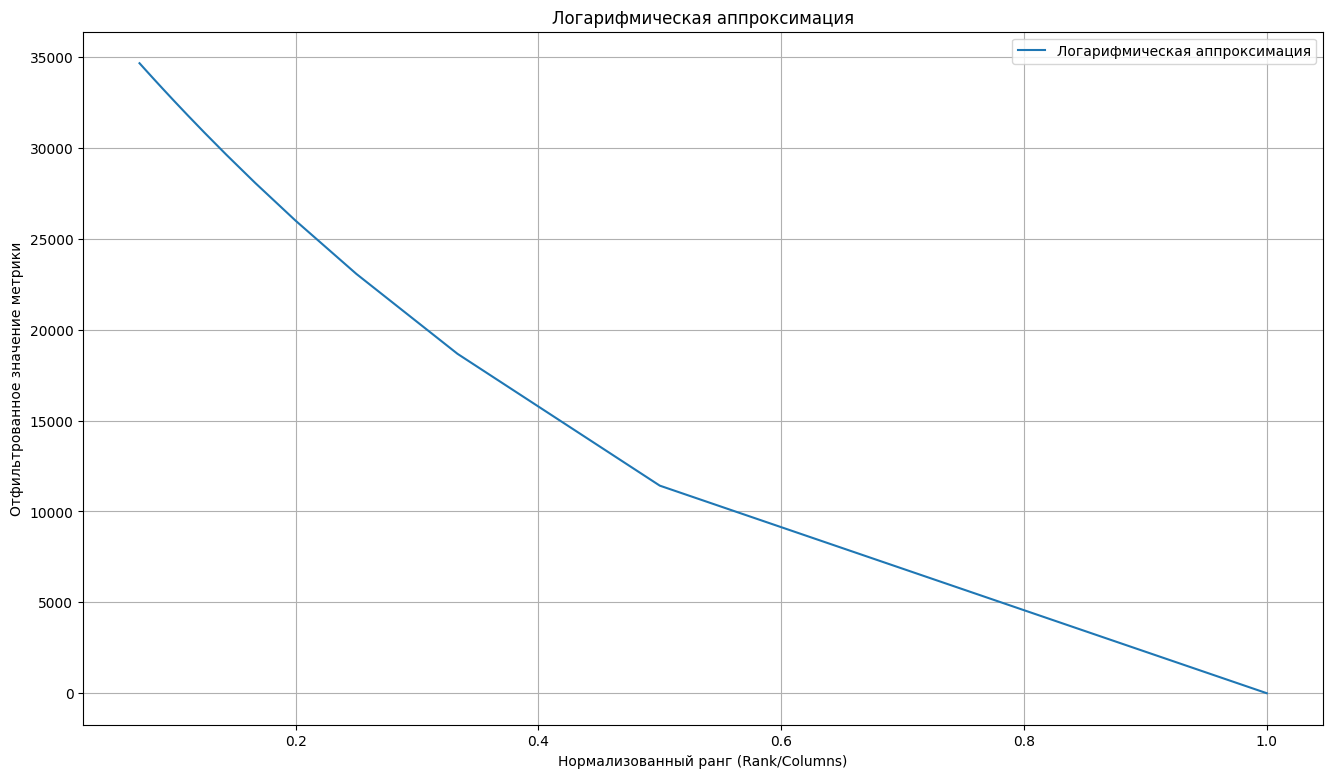

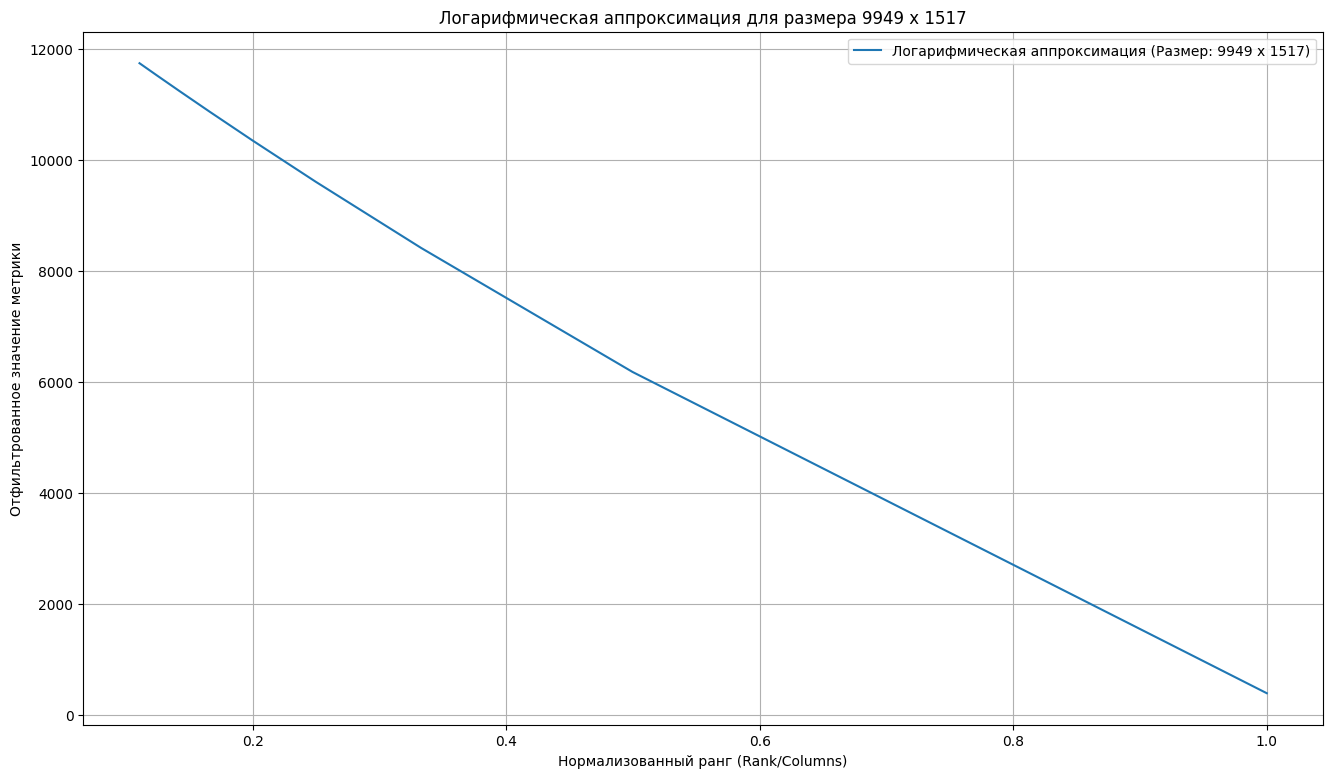

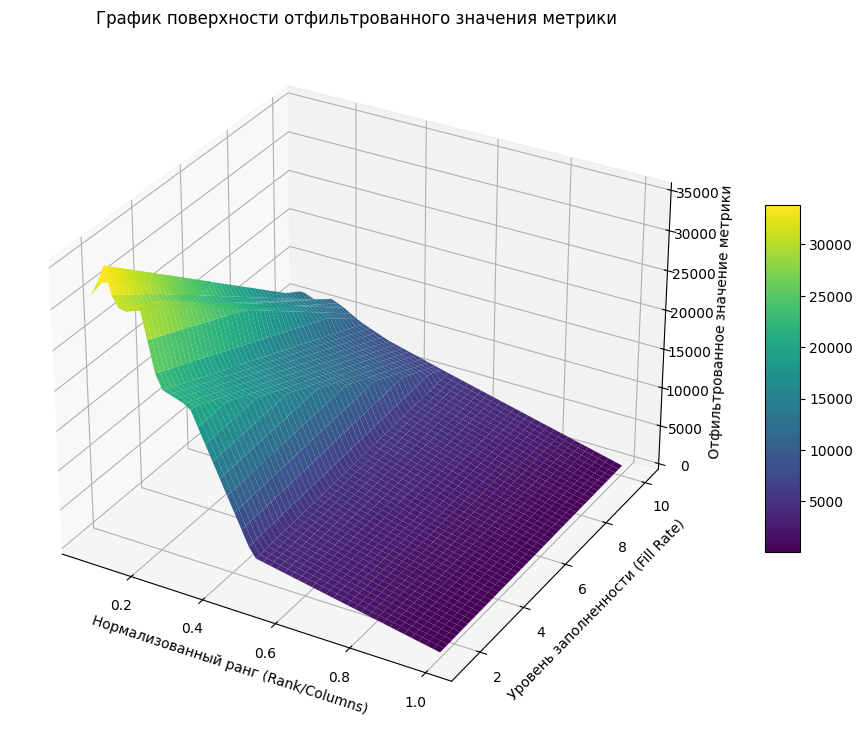

In [4]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

# Загрузка данных
file_path = 'for_plots.csv'  # Укажите путь к вашему CSV файлу
data = pd.read_csv(file_path)

# Определение функций для аппроксимации
def logarithmic(x, a, b, c):
    return a * np.log(x + 1) + b * x + c  # Добавление 1, чтобы избежать log(0)

# Подготовка данных для первого размера
size1_rows, size1_cols = 18896, 8124
filtered_data_size1 = data[(data['Rows'] == size1_rows) & (data['Columns'] == size1_cols)]
x_size1 = filtered_data_size1['Rank'] / filtered_data_size1['Columns']
y_size1 = filtered_data_size1['Filtered Metric Value']
popt_size1, _ = curve_fit(logarithmic, x_size1, y_size1, maxfev=10000)
y_fit_size1 = np.maximum(0, logarithmic(x_size1, *popt_size1))

# Построение аппроксимации для первого размера
plt.figure(figsize=(16, 9))
plt.plot(x_size1, y_fit_size1, '-', label=f"Логарифмическая аппроксимация")
plt.title(f"Логарифмическая аппроксимация")
plt.xlabel("Нормализованный ранг (Rank/Columns)")
plt.ylabel("Отфильтрованное значение метрики")
plt.grid()
plt.legend()
plt.show()

# Подготовка данных для второго размера
size2_rows, size2_cols = 9949, 1517
filtered_data_size2 = data[(data['Rows'] == size2_rows) & (data['Columns'] == size2_cols)]
x_size2 = filtered_data_size2['Rank'] / filtered_data_size2['Columns']
y_size2 = filtered_data_size2['Filtered Metric Value']
popt_size2, _ = curve_fit(logarithmic, x_size2, y_size2, maxfev=10000)
y_fit_size2 = np.maximum(0, logarithmic(x_size2, *popt_size2))

# Построение аппроксимации для второго размера
plt.figure(figsize=(16, 9))
plt.plot(x_size2, y_fit_size2, '-', label=f"Логарифмическая аппроксимация (Размер: {size2_rows} x {size2_cols})")
plt.title(f"Логарифмическая аппроксимация для размера {size2_rows} x {size2_cols}")
plt.xlabel("Нормализованный ранг (Rank/Columns)")
plt.ylabel("Отфильтрованное значение метрики")
plt.grid()
plt.legend()
plt.show()

# Объединение данных для построения поверхности
combined_data = pd.concat([
    filtered_data_size1.assign(Size=f"{size1_rows} x {size1_cols}"),
    filtered_data_size2.assign(Size=f"{size2_rows} x {size2_cols}")
])
combined_data['Normalized Rank'] = combined_data['Rank'] / combined_data['Columns']

x_combined = combined_data['Normalized Rank']
y_combined = combined_data['Fill Rate']
z_combined = combined_data['Filtered Metric Value']

# Создание сетки для построения поверхности
xi = np.linspace(x_combined.min(), x_combined.max(), 50)
yi = np.linspace(y_combined.min(), y_combined.max(), 50)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x_combined, y_combined), z_combined, (xi, yi), method='linear')

# Построение поверхности
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none')
ax.set_title("График поверхности отфильтрованного значения метрики")
ax.set_xlabel("Нормализованный ранг (Rank/Columns)")
ax.set_ylabel("Уровень заполненности (Fill Rate)")
ax.set_zlabel("Отфильтрованное значение метрики")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()
